# 01 — Data Profiling
## Nexora Supply Chain Analytics Platform

**Business objective:** understand the structure, quality, completeness, distribution, and business risks of the DataCo supply-chain dataset before any transformation.

**Dataset expectation:** approximately **180,519 rows × 53 columns**.  
**Grain:** one row represents one order item.

### Profiling scope
- Schema and data types
- Missing values and duplicates
- Cardinality and categorical consistency
- Descriptive statistics
- Date coverage
- Outliers using IQR
- Business-rule checks
- Data-quality summary and exportable reports

> Run this notebook before `02_data_cleaning.ipynb`.

## 1. Environment setup
The code supports both Google Colab upload and a file already stored in the runtime.

In [1]:
# Install only when a package is unavailable
import importlib.util, subprocess, sys

required = ['pandas', 'numpy', 'matplotlib', 'missingno', 'openpyxl']
for package in required:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 150)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('pandas:', pd.__version__)
print('Environment ready.')

pandas: 2.2.2
Environment ready.


## 2. Load the raw CSV
Set `FILE_PATH` manually or upload the CSV through Colab. The loader tries common encodings and verifies that the full dataset was read.

In [2]:
FILE_PATH = '/content/DataCoSupplyChainDataset.csv'  # change when needed
EXPECTED_MIN_ROWS = 180_000
EXPECTED_COLUMNS = 53


def resolve_input_file(file_path: str) -> str:
    if os.path.exists(file_path):
        return file_path

    try:
        from google.colab import files
        print('File not found. Upload DataCoSupplyChainDataset.csv ...')
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError('No file was uploaded.')
        return next(iter(uploaded.keys()))
    except ImportError as exc:
        raise FileNotFoundError(
            f'File not found at {file_path}. Set FILE_PATH to the correct CSV location.'
        ) from exc


def read_csv_robust(file_path: str) -> pd.DataFrame:
    errors = []
    for encoding in ('latin-1', 'utf-8', 'cp1252'):
        try:
            frame = pd.read_csv(file_path, encoding=encoding, low_memory=False)
            print(f'Loaded with encoding={encoding}')
            return frame
        except Exception as exc:
            errors.append(f'{encoding}: {exc}')
    raise RuntimeError('Unable to read CSV. ' + ' | '.join(errors))

FILE_PATH = resolve_input_file(FILE_PATH)
df_raw = read_csv_robust(FILE_PATH)

print(f'File      : {FILE_PATH}')
print(f'Rows      : {len(df_raw):,}')
print(f'Columns   : {df_raw.shape[1]:,}')
print(f'Memory MB : {df_raw.memory_usage(deep=True).sum()/1024**2:,.2f}')

if len(df_raw) < EXPECTED_MIN_ROWS:
    print(f'WARNING: only {len(df_raw):,} rows were loaded; expected about 180,519.')
else:
    print('Row-count check passed.')

if df_raw.shape[1] != EXPECTED_COLUMNS:
    print(f'WARNING: found {df_raw.shape[1]} columns; expected {EXPECTED_COLUMNS}.')
else:
    print('Column-count check passed.')

Loaded with encoding=latin-1
File      : /content/DataCoSupplyChainDataset.csv
Rows      : 4,010
Columns   : 53
Memory MB : 6.62
Column-count check passed.


In [3]:
display(df_raw.head())
display(df_raw.sample(min(5, len(df_raw)), random_state=42))

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,"20,755.00",1/31/2018 22:56,"77,202.00","1,360.00",13.11,0.04,"180,517.00",327.75,0.29,1.00,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,"1,360.00",73.00,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.00,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,"19,492.00",1/13/2018 12:27,"75,939.00","1,360.00",16.39,0.05,"179,254.00",327.75,-0.80,1.00,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,"1,360.00",73.00,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.00,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,"19,491.00",1/13/2018 12:06,"75,938.00","1,360.00",18.03,0.06,"179,253.00",327.75,-0.80,1.00,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,"1,360.00",73.00,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.00,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,"19,490.00",1/13/2018 11:45,"75,937.00","1,360.00",22.94,0.07,"179,252.00",327.75,0.08,1.00,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,"1,360.00",73.00,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.00,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,"19,489.00",1/13/2018 11:24,"75,936.00","1,360.00",29.50,0.09,"179,251.00",327.75,0.45,1.00,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,"1,360.00",73.00,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.00,1/15/2018 11:24,Standard Class


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
2580,TRANSFER,4,4,2.32,58.08,Shipping on time,0,7,Hockey,Longmont,EE. UU.,XXXXXXXXX,Larry,1921,Smith,XXXXXXXXX,Home Office,CO,3741 Sunny Lane,80501,2,Fitness,40.19,-105.10,LATAM,Medellín,Colombia,"1,921.00",3/9/2017 23:03,"54,733.00",135.00,7.92,0.12,"136,880.00",22.00,0.04,3.00,66.00,58.08,2.32,South America,Antioquía,PENDING,NaN,135.00,7.00,NaN,http://images.acmesports.sports/Nike+Dri-FIT+C...,Nike Dri-FIT Crew Sock 6 Pack,22.00,0.00,3/13/2017 23:03,Standard Class
3661,CASH,2,1,34.65,98.99,Late delivery,1,9,Cardio Equipment,Caguas,Puerto Rico,XXXXXXXXX,Randy,11048,Ball,XXXXXXXXX,Corporate,PR,2743 Hidden Blossom Square,725,3,Footwear,18.24,-66.37,LATAM,Chihuahua,México,"11,048.00",5/18/2015 19:57,"9,443.00",191.00,1.00,0.01,"23,580.00",99.99,0.35,1.00,99.99,98.99,34.65,Central America,Chihuahua,CLOSED,NaN,191.00,9.00,NaN,http://images.acmesports.sports/Nike+Men%27s+F...,Nike Men's Free 5.0+ Running Shoe,99.99,0.00,5/20/2015 19:57,First Class
897,DEBIT,4,4,11.31,113.09,Shipping on time,0,18,Men's Footwear,Columbus,EE. UU.,XXXXXXXXX,Mary,6897,Howard,XXXXXXXXX,Corporate,GA,4720 Colonial Blossom Run,31907,4,Apparel,32.52,-84.89,Pacific Asia,Estambul,Turquía,"6,897.00",12/29/2016 5:38,"49,888.00",403.00,16.90,0.13,"124,741.00",129.99,0.10,1.00,129.99,113.09,11.31,West Asia,Estambul,COMPLETE,NaN,403.00,18.00,NaN,http://images.acmesports.sports/Nike+Men%27s+C...,Nike Men's CJ Elite 2 TD Football Cleat,129.99,0.00,1/2/2017 5:38,Standard Class
2091,DEBIT,6,4,17.40,173.96,Late delivery,1,29,Shop By Sport,Hyattsville,EE. UU.,XXXXXXXXX,Mary,3046,Newman,XXXXXXXXX,Consumer,MD,5578 Hazy River End,20783,5,Golf,38.99,-76.98,Europe,Mougins,Francia,"3,046.00",6/28/2015 14:06,"12,235.00",627.00,25.99,0.13,"30,572.00",39.99,0.10,5.00,199.95,173.96,17.40,Western Europe,Provenza-Alpes-Costa Azul,COMPLETE,NaN,627.00,29.00,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.99,0.00,7/4/2015 14:06,Standard Class
1044,TRANSFER,3,4,16.18,67.98,Advance shipping,0,29,Shop By Sport,Los Angeles,EE. UU.,XXXXXXXXX,Mary,11675,Smith,XXXXXXXXX,Corporate,CA,516 Dewy Bluff Swale,90024,5,Golf,34.05,-118.25,Pacific Asia,Perth,Australia,"11,675.00",11/27/2015 1:38,"22,612.00",627.00,12.00,0.15,"56,568.00",39.99,0.24,2.00,79.98,67.98,16.18,Oceania,Australia Occidental,PENDING,NaN,627.00,29.00,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.99,0.00,11/30/2015 1:38,Standard Class


## 3. Dataset overview and schema

In [4]:
overview = pd.DataFrame({
    'metric': ['rows', 'columns', 'cells', 'memory_mb', 'exact_duplicate_rows'],
    'value': [
        len(df_raw),
        df_raw.shape[1],
        df_raw.size,
        round(df_raw.memory_usage(deep=True).sum()/1024**2, 2),
        int(df_raw.duplicated().sum())
    ]
})
display(overview)

schema_report = pd.DataFrame({
    'column': df_raw.columns,
    'dtype': df_raw.dtypes.astype(str).values,
    'non_null': df_raw.notna().sum().values,
    'null_count': df_raw.isna().sum().values,
    'null_pct': (df_raw.isna().mean().values * 100).round(2),
    'unique_count': [df_raw[c].nunique(dropna=True) for c in df_raw.columns],
    'sample_value': [df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else None for c in df_raw.columns]
}).sort_values(['null_pct', 'unique_count'], ascending=[False, False])

display(schema_report)

,metric,value
0,rows,"4,010.00"
1,columns,53.00
2,cells,"212,530.00"
3,memory_mb,6.62
4,exact_duplicate_rows,0.00


,column,dtype,non_null,null_count,null_pct,unique_count,sample_value
46,Product Description,float64,0,4010,100.00,0,None
43,Order Zipcode,float64,271,3739,93.24,139,"99,301.00"
33,Order Item Id,float64,4009,1,0.02,4009,"180,517.00"
28,order date (DateOrders),object,4009,1,0.02,3190,1/31/2018 22:56
29,Order Id,float64,4009,1,0.02,3190,"77,202.00"
51,shipping date (DateOrders),object,4009,1,0.02,3185,2/3/2018 22:56
39,Order Profit Per Order,float64,4009,1,0.02,3079,91.25
27,Order Customer Id,float64,4009,1,0.02,2859,"20,755.00"
22,Latitude,float64,4009,1,0.02,2442,18.25
25,Order City,object,4009,1,0.02,1354,Bekasi


## 4. Missing-value analysis

,column,missing_count,missing_pct
46,Product Description,4010,100.00
43,Order Zipcode,3739,93.24
22,Latitude,1,0.02
25,Order City,1,0.02
26,Order Country,1,0.02
23,Longitude,1,0.02
24,Market,1,0.02
29,Order Id,1,0.02
30,Order Item Cardprod Id,1,0.02
31,Order Item Discount,1,0.02


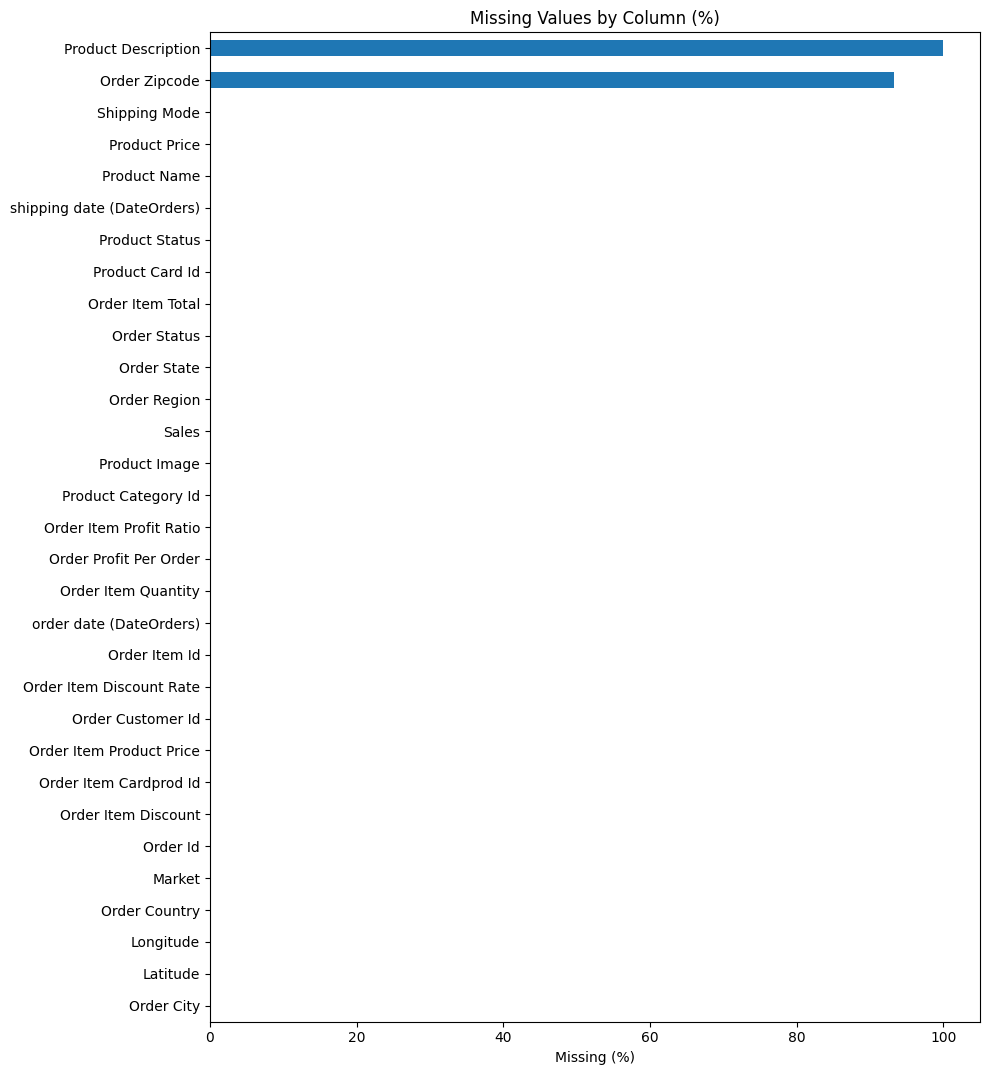

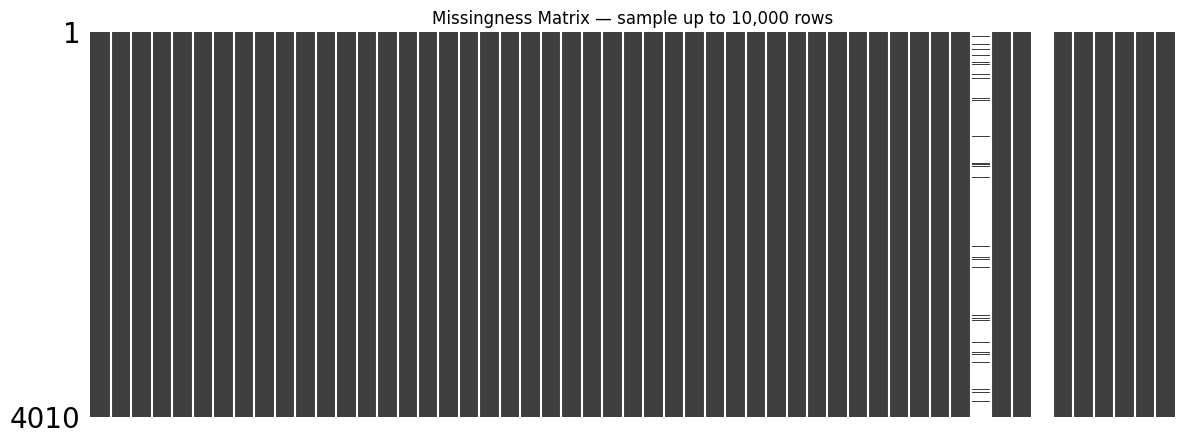

In [5]:
missing_report = (
    pd.DataFrame({
        'column': df_raw.columns,
        'missing_count': df_raw.isna().sum().values,
        'missing_pct': (df_raw.isna().mean().values * 100).round(2)
    })
    .query('missing_count > 0')
    .sort_values('missing_pct', ascending=False)
)

display(missing_report if not missing_report.empty else pd.DataFrame({'result':['No missing values found']}))

if not missing_report.empty:
    ax = missing_report.sort_values('missing_pct').plot(
        x='column', y='missing_pct', kind='barh', figsize=(10, max(4, len(missing_report)*0.35)), legend=False
    )
    ax.set_title('Missing Values by Column (%)')
    ax.set_xlabel('Missing (%)')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

    msno.matrix(df_raw.sample(min(10_000, len(df_raw)), random_state=42), figsize=(14, 5), sparkline=False)
    plt.title('Missingness Matrix — sample up to 10,000 rows')
    plt.show()

## 5. Duplicate and key-integrity checks
`Order Item Id` should identify a unique order-item record. Exact duplicates and duplicated keys are reported separately.

In [6]:
exact_duplicates = int(df_raw.duplicated().sum())

key_candidates = ['Order Item Id', 'Order Id', 'Customer Id', 'Product Card Id']
key_checks = []
for col in key_candidates:
    if col in df_raw.columns:
        key_checks.append({
            'column': col,
            'missing': int(df_raw[col].isna().sum()),
            'unique': int(df_raw[col].nunique(dropna=True)),
            'duplicated_rows': int(df_raw[col].duplicated(keep=False).sum()),
            'is_unique': bool(df_raw[col].is_unique)
        })

print(f'Exact duplicate rows: {exact_duplicates:,}')
display(pd.DataFrame(key_checks))

if 'Order Item Id' in df_raw.columns:
    duplicate_order_items = df_raw[df_raw['Order Item Id'].duplicated(keep=False)].sort_values('Order Item Id')
    print(f'Duplicate Order Item Id rows: {len(duplicate_order_items):,}')
    display(duplicate_order_items.head(10))

Exact duplicate rows: 0


,column,missing,unique,duplicated_rows,is_unique
0,Order Item Id,1,4009,0,True
1,Order Id,1,3190,1435,False
2,Customer Id,0,2859,1922,False
3,Product Card Id,1,80,3996,False


Duplicate Order Item Id rows: 0


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode


## 6. Numeric profiling and distributions

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,zero_count,negative_count
Days for shipping (real),"4,010.00",3.69,1.55,0.00,0.00,2.00,2.00,4.00,5.00,6.00,6.00,6.00,0,53,0
Days for shipment (scheduled),"4,010.00",3.08,1.24,0.00,0.00,1.00,2.00,4.00,4.00,4.00,4.00,4.00,0,127,0
Benefit per order,"4,010.00",20.87,104.11,-989.95,-425.14,-149.54,6.01,29.29,65.98,133.91,185.14,599.25,0,22,767
Sales per customer,"4,010.00",182.49,127.41,9.26,19.40,36.96,96.80,151.96,263.98,387.98,479.95,"1,417.50",0,0,0
Late_delivery_risk,"4,010.00",0.54,0.50,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,0,1847,0
Category Id,"4,010.00",28.62,20.04,2.00,7.00,7.00,17.00,24.00,40.00,73.00,73.00,76.00,0,0,0
Customer Id,"4,010.00","7,857.92","5,186.24",8.00,155.00,639.45,"3,710.50","7,351.50","10,852.00","19,311.55","19,471.91","20,755.00",0,0,0
Customer Zipcode,"4,010.00","24,755.80","35,187.84",603.00,725.00,725.00,725.00,725.00,"48,098.00","93,063.00","96,822.00","98,052.00",0,0,0
Department Id,"4,010.00",4.30,1.70,2.00,2.00,2.00,3.00,4.00,5.00,7.00,10.00,12.00,0,0,0
Latitude,"4,009.00",26.28,9.80,17.98,18.15,18.21,18.24,18.29,35.58,42.10,44.72,47.84,1,0,0


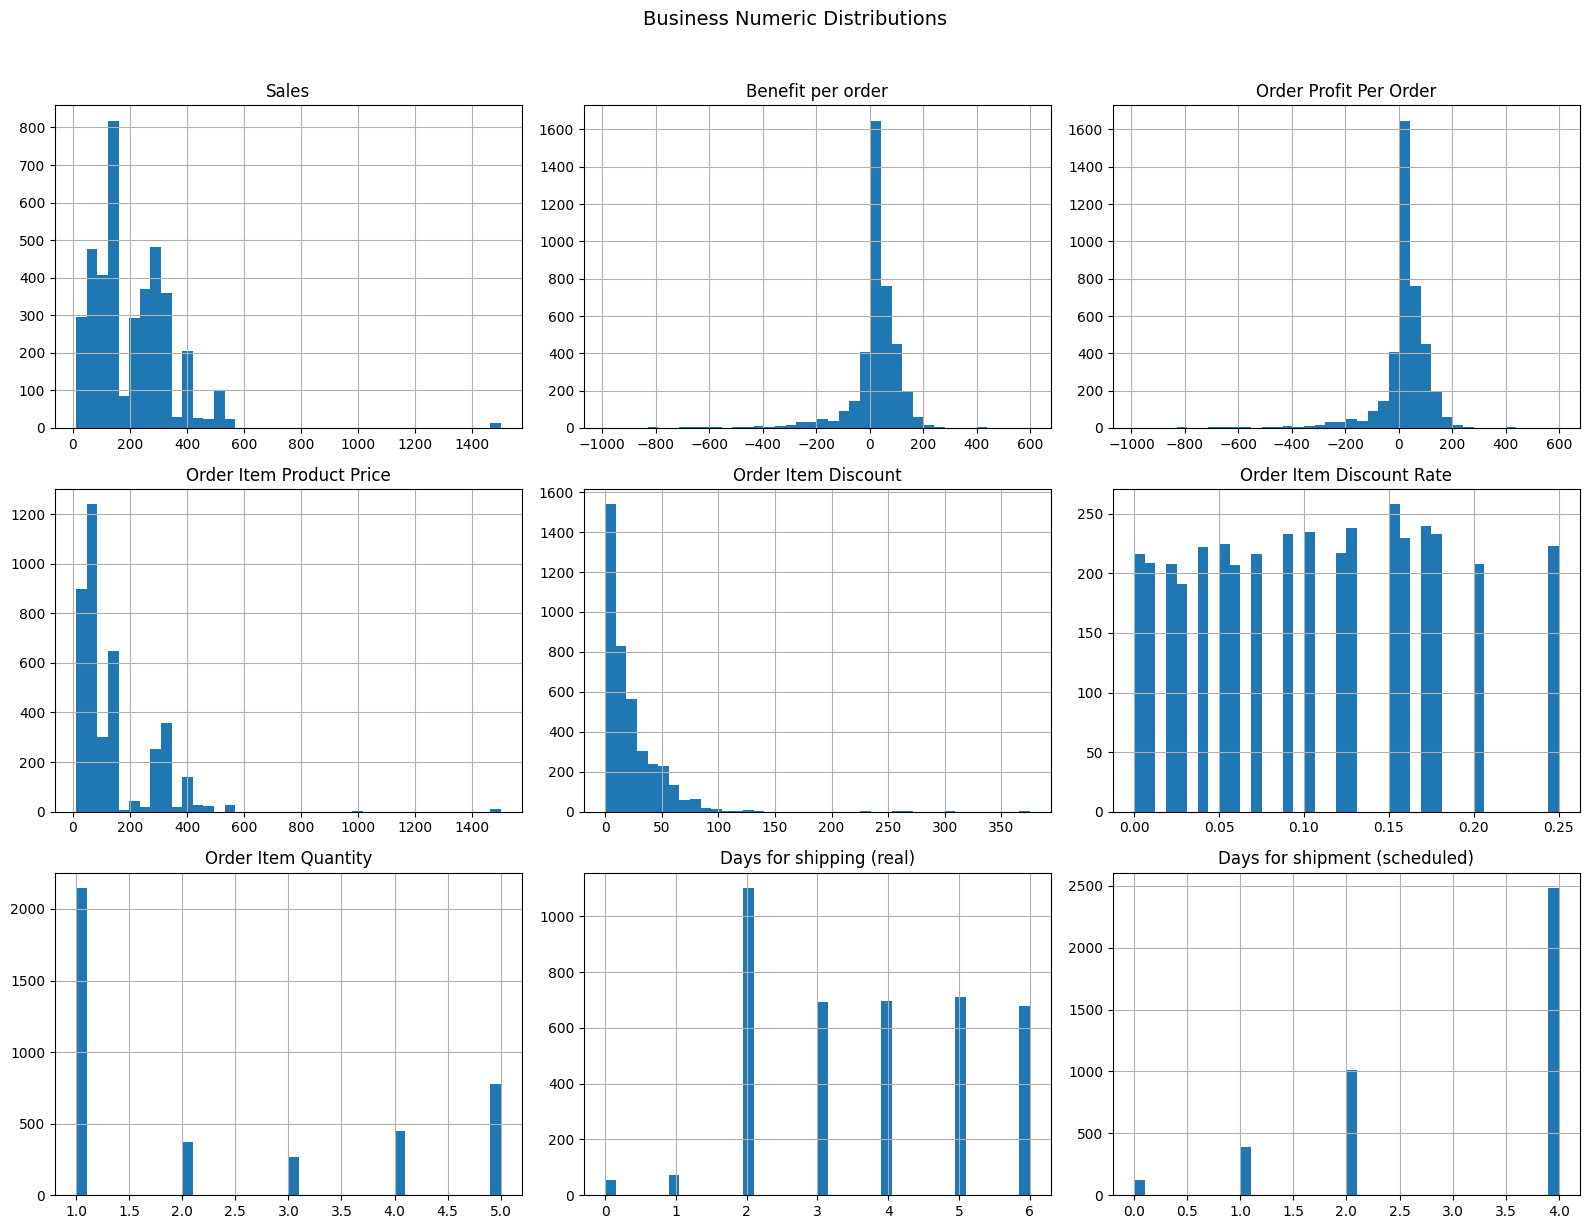

In [7]:
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()

numeric_profile = df_raw[numeric_cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
numeric_profile['missing'] = df_raw[numeric_cols].isna().sum()
numeric_profile['zero_count'] = (df_raw[numeric_cols] == 0).sum()
numeric_profile['negative_count'] = (df_raw[numeric_cols] < 0).sum()
display(numeric_profile)

business_numeric = [c for c in [
    'Sales', 'Benefit per order', 'Order Profit Per Order',
    'Order Item Product Price', 'Order Item Discount',
    'Order Item Discount Rate', 'Order Item Quantity',
    'Days for shipping (real)', 'Days for shipment (scheduled)'
] if c in df_raw.columns]

if business_numeric:
    df_raw[business_numeric].hist(figsize=(16, 12), bins=40)
    plt.suptitle('Business Numeric Distributions', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. Categorical profiling

In [8]:
categorical_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_profile = pd.DataFrame({
    'column': categorical_cols,
    'unique_count': [df_raw[c].nunique(dropna=True) for c in categorical_cols],
    'missing_count': [df_raw[c].isna().sum() for c in categorical_cols],
    'top_value': [df_raw[c].mode(dropna=True).iloc[0] if not df_raw[c].mode(dropna=True).empty else None for c in categorical_cols],
    'top_frequency': [df_raw[c].value_counts(dropna=True).iloc[0] if not df_raw[c].value_counts(dropna=True).empty else 0 for c in categorical_cols]
}).sort_values('unique_count')

display(categorical_profile)

important_categories = [c for c in [
    'Delivery Status', 'Late_delivery_risk', 'Shipping Mode', 'Order Status',
    'Market', 'Order Region', 'Customer Segment', 'Category Name'
] if c in df_raw.columns]

for col in important_categories:
    print(f'\n--- {col} ---')
    display(df_raw[col].value_counts(dropna=False).head(20).rename('count').to_frame())

,column,unique_count,missing_count,top_value,top_frequency
5,Customer Email,1,0,XXXXXXXXX,4010
8,Customer Password,1,0,XXXXXXXXX,4010
4,Customer Country,2,0,Puerto Rico,2299
9,Customer Segment,3,0,Consumer,1964
0,Type,4,0,DEBIT,1595
1,Delivery Status,4,0,Late delivery,2163
23,Shipping Mode,4,1,Standard Class,2481
13,Market,5,1,Pacific Asia,1330
19,Order Status,9,1,COMPLETE,1442
12,Department Name,12,0,Apparel,1351



--- Delivery Status ---


,count
Delivery Status,
Late delivery,2163
Advance shipping,927
Shipping on time,700
Shipping canceled,220



--- Late_delivery_risk ---


,count
Late_delivery_risk,
1,2163
0,1847


...

,count
Order Region,
Western Europe,698
Central America,442
Oceania,342
Southeast Asia,300
South America,279
Eastern Asia,275
Northern Europe,268
South Asia,247
Southern Europe,245



--- Customer Segment ---


,count
Customer Segment,
Consumer,1964
Corporate,1262
Home Office,784



--- Category Name ---


,count
Category Name,
Men's Footwear,647
Cleats,614
Women's Apparel,564
Sporting Goods,357
Hockey,355
Cardio Equipment,299
Shop By Sport,277
Camping & Hiking,242
Fishing,139


## 8. Date profiling

In [9]:
date_columns = [c for c in ['order date (DateOrders)', 'shipping date (DateOrders)'] if c in df_raw.columns]
date_report = []

for col in date_columns:
    parsed = pd.to_datetime(df_raw[col], errors='coerce')
    date_report.append({
        'column': col,
        'min_date': parsed.min(),
        'max_date': parsed.max(),
        'invalid_or_missing': int(parsed.isna().sum()),
        'distinct_dates': int(parsed.dt.date.nunique())
    })

display(pd.DataFrame(date_report))

,column,min_date,max_date,invalid_or_missing,distinct_dates
0,order date (DateOrders),2015-01-01 19:58:00,2018-01-31 22:56:00,1,997
1,shipping date (DateOrders),2015-01-04 16:17:00,2018-02-05 14:43:00,1,1011


## 9. Outlier analysis using the IQR rule
Outliers are flagged for diagnosis, not automatically removed. Large orders, high discounts, and losses may be valid business events.

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
3,Order Item Product Price,50.00,129.99,79.99,-69.99,249.98,876,21.85
2,Order Profit Per Order,6.00,65.98,59.98,-83.97,155.95,390,9.73
1,Benefit per order,6.01,65.98,59.97,-83.95,155.94,390,9.73
4,Order Item Discount,5.20,30.00,24.80,-32.00,67.20,172,4.29
0,Sales,100.00,299.98,199.98,-199.97,599.95,13,0.32
5,Order Item Quantity,1.00,4.00,3.00,-3.50,8.50,0,0.00
6,Days for shipping (real),2.00,5.00,3.00,-2.50,9.50,0,0.00


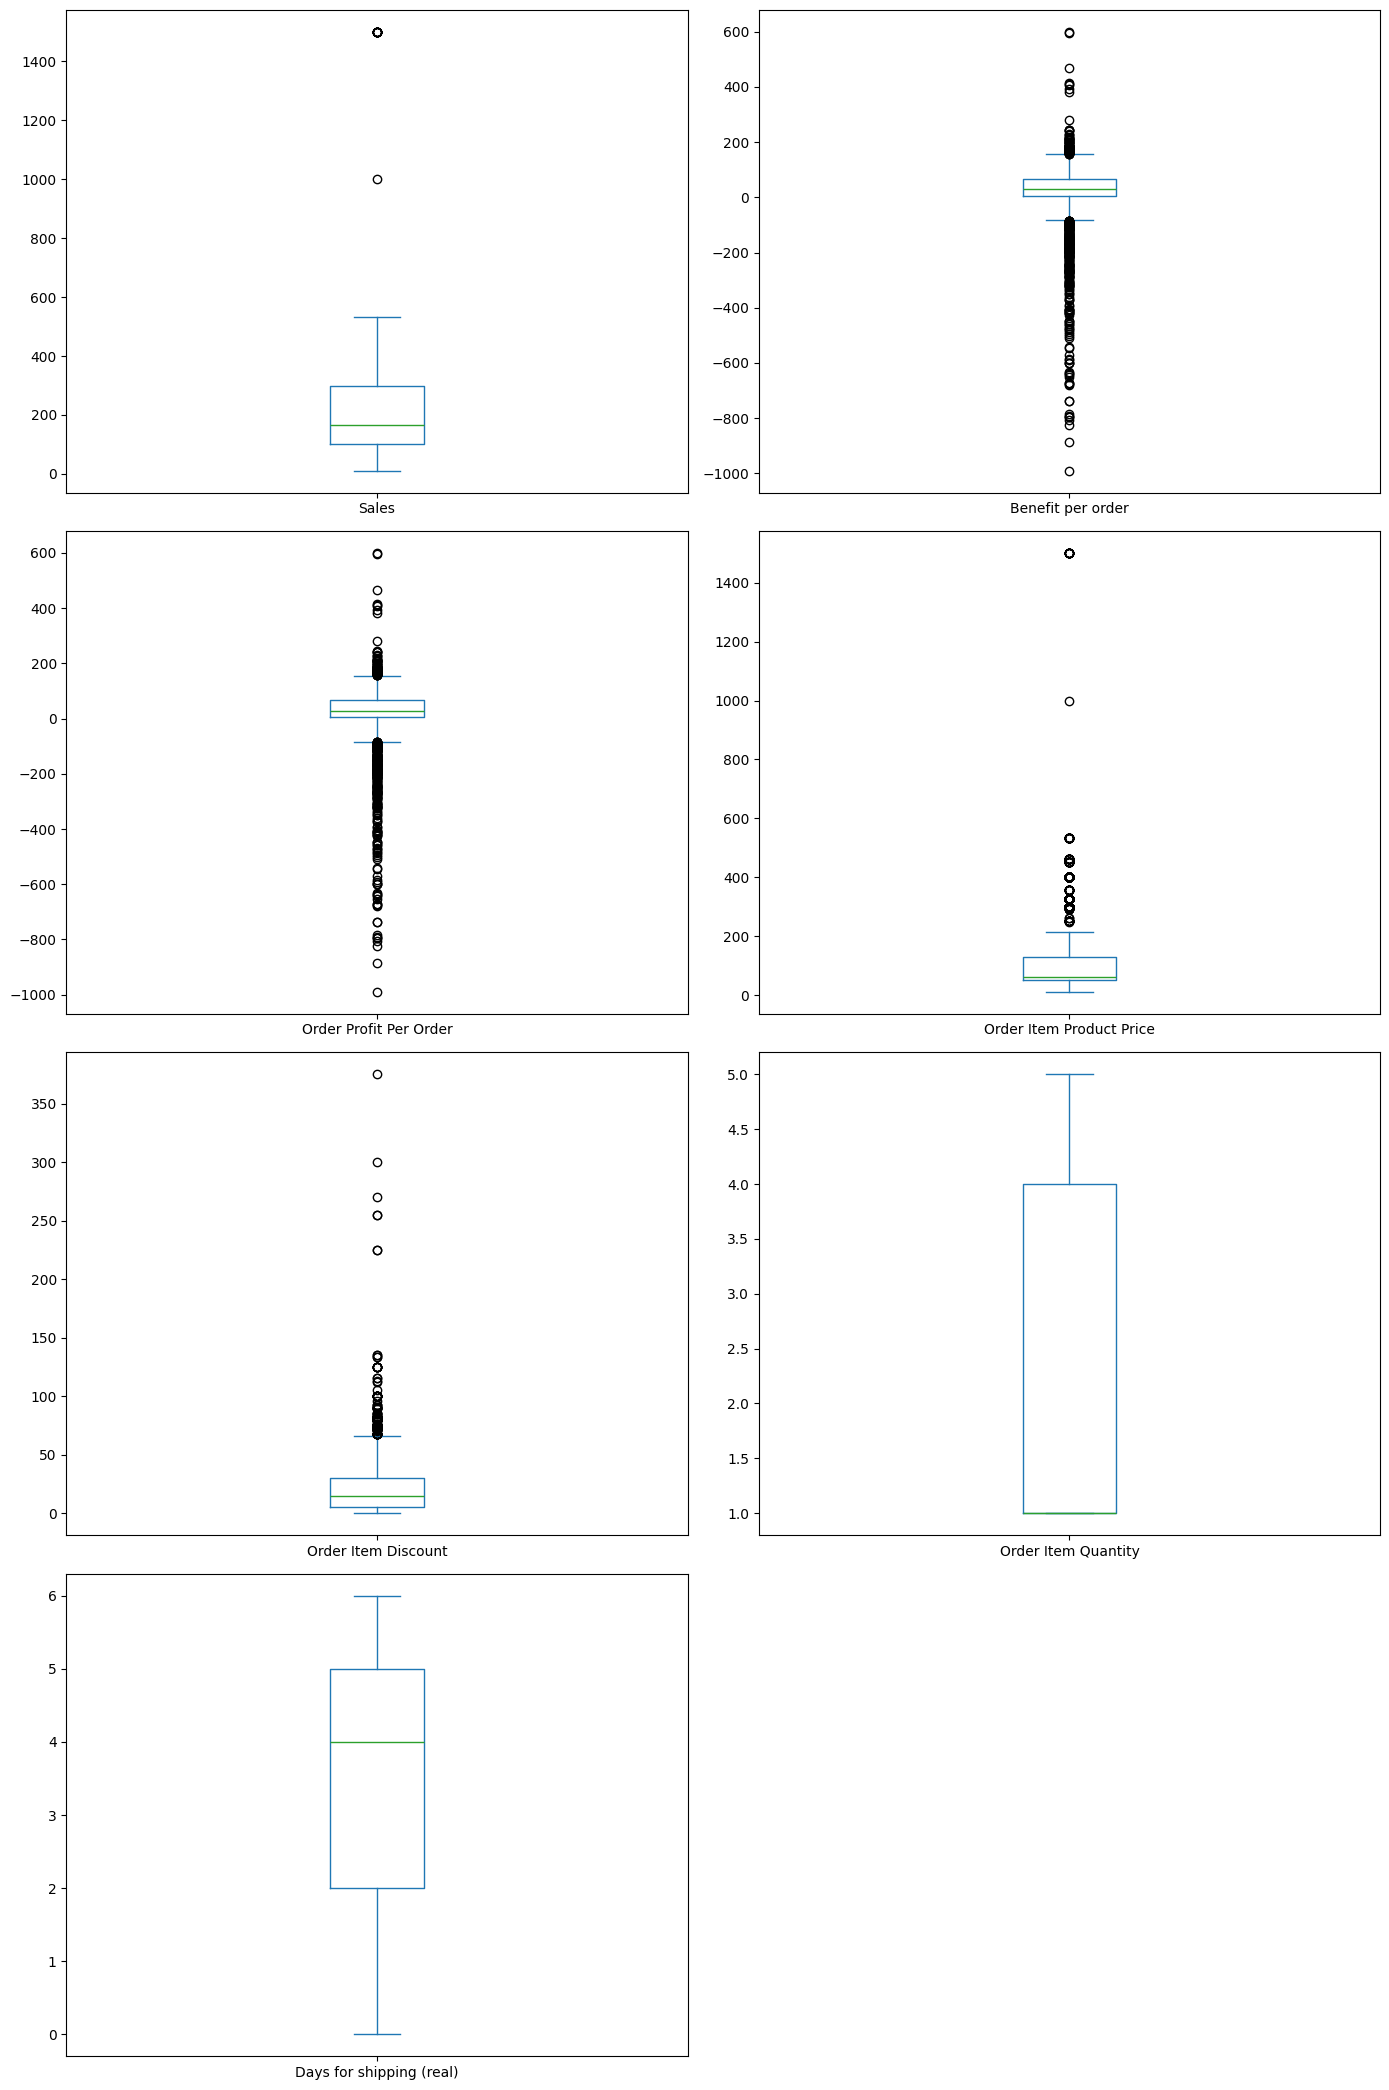

In [10]:
outlier_columns = [c for c in [
    'Sales', 'Benefit per order', 'Order Profit Per Order',
    'Order Item Product Price', 'Order Item Discount',
    'Order Item Quantity', 'Days for shipping (real)'
] if c in df_raw.columns]

outlier_rows = []
for col in outlier_columns:
    s = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = int(((s < lower) | (s > upper)).sum())
    outlier_rows.append({
        'column': col, 'q1': q1, 'q3': q3, 'iqr': iqr,
        'lower_bound': lower, 'upper_bound': upper,
        'outlier_count': count, 'outlier_pct': round(count/len(s)*100, 2)
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)
display(outlier_report)

if outlier_columns:
    df_raw[outlier_columns].plot(kind='box', subplots=True, layout=(-1, 2), figsize=(14, 3*len(outlier_columns)), sharex=False)
    plt.tight_layout()
    plt.show()

## 10. Business-rule validation
These checks reveal inconsistencies that must be addressed or documented during cleaning.

In [11]:
checks = []

def add_check(name, mask, severity='high'):
    mask = pd.Series(mask, index=df_raw.index).fillna(False)
    checks.append({
        'check': name,
        'severity': severity,
        'failed_rows': int(mask.sum()),
        'failed_pct': round(mask.mean()*100, 4),
        'status': 'PASS' if mask.sum() == 0 else 'REVIEW'
    })

if {'Days for shipping (real)', 'Days for shipment (scheduled)'}.issubset(df_raw.columns):
    add_check('Negative actual shipping days', df_raw['Days for shipping (real)'] < 0)
    add_check('Negative scheduled shipping days', df_raw['Days for shipment (scheduled)'] < 0)

if 'Order Item Quantity' in df_raw.columns:
    add_check('Quantity must be greater than zero', df_raw['Order Item Quantity'] <= 0)
if 'Sales' in df_raw.columns:
    add_check('Sales must be non-negative', df_raw['Sales'] < 0)
if 'Order Item Product Price' in df_raw.columns:
    add_check('Product price must be non-negative', df_raw['Order Item Product Price'] < 0)
if 'Order Item Discount Rate' in df_raw.columns:
    add_check('Discount rate outside 0–1', ~df_raw['Order Item Discount Rate'].between(0, 1, inclusive='both'))
if 'Late_delivery_risk' in df_raw.columns:
    add_check('Late delivery risk outside {0,1}', ~df_raw['Late_delivery_risk'].isin([0, 1]))
if 'Order Item Id' in df_raw.columns:
    add_check('Missing Order Item Id', df_raw['Order Item Id'].isna())
    add_check('Duplicated Order Item Id', df_raw['Order Item Id'].duplicated(keep=False))

# Cross-field consistency: delivery status and late-risk flag
if {'Delivery Status', 'Late_delivery_risk'}.issubset(df_raw.columns):
    status = df_raw['Delivery Status'].astype(str).str.strip().str.lower()
    risk = pd.to_numeric(df_raw['Late_delivery_risk'], errors='coerce')
    inconsistency = ((status == 'late delivery') & (risk != 1)) | ((status != 'late delivery') & (risk == 1) & status.notna())
    add_check('Delivery status vs late-risk inconsistency', inconsistency, severity='medium')

business_rule_report = pd.DataFrame(checks)
display(business_rule_report)

,check,severity,failed_rows,failed_pct,status
0,Negative actual shipping days,high,0,0.00,PASS
1,Negative scheduled shipping days,high,0,0.00,PASS
2,Quantity must be greater than zero,high,0,0.00,PASS
3,Sales must be non-negative,high,0,0.00,PASS
4,Product price must be non-negative,high,0,0.00,PASS
5,Discount rate outside 0–1,high,1,0.02,REVIEW
6,"Late delivery risk outside {0,1}",high,0,0.00,PASS
7,Missing Order Item Id,high,1,0.02,REVIEW
8,Duplicated Order Item Id,high,0,0.00,PASS
9,Delivery status vs late-risk inconsistency,medium,0,0.00,PASS


## 11. Data-quality score and profiling conclusion
The score is a transparent baseline, not an absolute certification.

- Completeness: non-null cell ratio
- Uniqueness: exact-row uniqueness
- Validity: proportion passing business rules
- Schema: expected column-count check

In [12]:
completeness = 1 - (df_raw.isna().sum().sum() / df_raw.size)
uniqueness = 1 - (df_raw.duplicated().sum() / len(df_raw))
validity = 1 - (business_rule_report['failed_rows'].sum() / (len(df_raw) * max(len(business_rule_report), 1)))
schema_score = 1.0 if df_raw.shape[1] == EXPECTED_COLUMNS else 0.5

quality_dimensions = pd.DataFrame({
    'dimension': ['completeness', 'uniqueness', 'validity', 'schema'],
    'score_pct': [completeness*100, uniqueness*100, max(0, validity)*100, schema_score*100],
    'weight': [0.30, 0.25, 0.30, 0.15]
})
quality_dimensions['weighted_score'] = quality_dimensions['score_pct'] * quality_dimensions['weight']
readiness_score = quality_dimensions['weighted_score'].sum()

display(quality_dimensions)
print(f'RAW DATA READINESS SCORE: {readiness_score:.2f}/100')

if readiness_score >= 95:
    print('Assessment: strong baseline; proceed with controlled cleaning.')
elif readiness_score >= 85:
    print('Assessment: usable after documented cleaning and validation.')
else:
    print('Assessment: material quality issues require remediation before analytics.')

,dimension,score_pct,weight,weighted_score
0,completeness,96.34,0.30,28.90
1,uniqueness,100.00,0.25,25.00
2,validity,100.00,0.30,30.00
3,schema,100.00,0.15,15.00


RAW DATA READINESS SCORE: 98.90/100
Assessment: strong baseline; proceed with controlled cleaning.


## 12. Export profiling reports
The reports can be committed to `data/interim/` or attached to project documentation.

In [13]:
OUTPUT_DIR = Path('/content/profiling_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

schema_report.to_csv(OUTPUT_DIR / 'schema_report.csv', index=False)
missing_report.to_csv(OUTPUT_DIR / 'missing_value_report.csv', index=False)
numeric_profile.to_csv(OUTPUT_DIR / 'numeric_profile.csv')
categorical_profile.to_csv(OUTPUT_DIR / 'categorical_profile.csv', index=False)
outlier_report.to_csv(OUTPUT_DIR / 'outlier_report.csv', index=False)
business_rule_report.to_csv(OUTPUT_DIR / 'business_rule_report.csv', index=False)
quality_dimensions.to_csv(OUTPUT_DIR / 'data_quality_score.csv', index=False)

with pd.ExcelWriter(OUTPUT_DIR / 'data_profiling_report.xlsx', engine='openpyxl') as writer:
    overview.to_excel(writer, sheet_name='overview', index=False)
    schema_report.to_excel(writer, sheet_name='schema', index=False)
    missing_report.to_excel(writer, sheet_name='missing', index=False)
    numeric_profile.to_excel(writer, sheet_name='numeric')
    categorical_profile.to_excel(writer, sheet_name='categorical', index=False)
    outlier_report.to_excel(writer, sheet_name='outliers', index=False)
    business_rule_report.to_excel(writer, sheet_name='business_rules', index=False)
    quality_dimensions.to_excel(writer, sheet_name='quality_score', index=False)

print('Saved reports to:', OUTPUT_DIR)
print(*[p.name for p in OUTPUT_DIR.iterdir()], sep='\n- ')

Saved reports to: /content/profiling_outputs
schema_report.csv
- missing_value_report.csv
- numeric_profile.csv
- data_quality_score.csv
- outlier_report.csv
- business_rule_report.csv
- categorical_profile.csv
- data_profiling_report.xlsx


## Completion checklist
- [ ] Row count is close to 180,519
- [ ] Column count is 53
- [ ] Missing values have been reviewed
- [ ] Exact duplicates and key duplicates have been measured
- [ ] Date range is reasonable
- [ ] Outliers are documented, not blindly removed
- [ ] Business-rule failures are understood
- [ ] Profiling reports have been exported

**Next:** run `02_data_cleaning.ipynb`.